# Intermediate Python for the Memory Game Competition 🧠🎮

This notebook is a **reference and practice session**, not a hardware notebook. There's no
FPGA, no camera, no DPU here — just the core Python ideas you'll want to be comfortable with
before the end-of-week competition.

**How to use this notebook:**
- Each section below is **standalone** — you can jump to whichever concept you're fuzzy on.
- Every section has: a plain-English explanation, a small toy example, and a **mini exercise**
  for you to try.
- Exercise solutions are in a collapsed cell right after each exercise — try it yourself first!

**Sections:**
1. Variables & f-strings
2. Functions & default arguments
3. Dictionaries as mini "objects"
4. Lists, tuples & unpacking
5. Sets & set operations
6. Comprehensions
7. `enumerate()` and `zip()`
8. Sorting with `key=` and `lambda`
9. `global` and shared state
10. Errors: `try` / `except` / `raise`
11. Strings: slicing & parsing
12. NumPy arrays
13. OpenCV image basics

Let's go! 🚀

## 1. Variables & f-strings

An **f-string** (`f"..."`) lets you drop variables directly into text using `{ }`. You can even
format numbers inside the braces, like rounding a decimal to 2 places with `:.2f`.

In [1]:
temperature = 72.4863
city = "Denver"
condition = "sunny"

# Basic f-string
print(f"{city} is currently {condition}")

# f-string with number formatting: :.2f means "2 digits after the decimal"
print(f"{city} is currently {condition} at {temperature:.2f} degrees")

Denver is currently sunny
Denver is currently sunny at 72.49 degrees


### 🏋️ Mini Exercise
Given `student_name = "Ada"` and `quizzes_completed = 3`, print:

```
Ada has completed 3 quizzes so far!
```

using an f-string.

In [2]:
student_name = "Ada"
quizzes_completed = 3

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
print(f"{student_name} has completed {quizzes_completed} quizzes so far!")
```
</details>

## 2. Functions & default arguments

A function can have **default argument values** — if the caller doesn't pass that argument,
Python uses the default. This lets you write flexible helpers without forcing every caller to
specify every setting.

In [3]:
def greet(name, greeting="Welcome"):
    return f"{greeting}, {name}!"

print(greet("Sam"))                  # uses the default greeting
print(greet("Sam", greeting="Hi"))    # overrides it

Welcome, Sam!
Hi, Sam!


### 🏋️ Mini Exercise
Write a function `describe_item(name, confidence=1.0)` that returns a string like:

```
backpack (confidence 1.00)
```

Call it once with just a name, and once passing a custom confidence.

In [4]:
# your code here
def describe_item(name, confidence=1.0):
    pass

print(describe_item("backpack"))
print(describe_item("water bottle", confidence=0.87))

None
None


<details><summary>💡 Solution (click to expand)</summary>

```python
def describe_item(name, confidence=1.0):
    return f"{name} (confidence {confidence:.2f})"

print(describe_item("backpack"))
print(describe_item("water bottle", confidence=0.87))
```
</details>

## 3. Dictionaries as mini "objects"

A **dictionary** stores related values together under labeled keys, like a labeled box of
values:

```python
robot = {
    'sensors': {},
    'active_alerts': set(),
    'battery': 100,
}
```

Three dictionary methods you'll use constantly:
- `.get(key, default)` — read a value, or return `default` if the key isn't there (no crash!)
- `.setdefault(key, default)` — like `.get()`, but also *stores* the default if missing
- `.pop(key, default)` — remove a key and return its value (or `default` if missing)

In [5]:
robot = {"name": "Rover", "battery": 80}

# .get() is a safe way to read a value that might not exist
print(robot.get("battery"))          # 80
print(robot.get("speed", 1))         # "speed" isn't in the dict, so we get 1 back

# .setdefault() reads OR creates-and-reads
robot.setdefault("speed", 1)
print(robot)                          # 'speed': 1 has now been added

# .pop() removes a key and gives you its value
speed = robot.pop("speed")
print(speed, robot)

80
1
{'name': 'Rover', 'battery': 80, 'speed': 1}
1 {'name': 'Rover', 'battery': 80}


### 🏋️ Mini Exercise
You're tracking sensor readings in `sensors = {"front": "clear", "left": "obstacle"}`.

1. Use `.get()` to safely look up `"right"` with a default of `"unknown"`.
2. Use `.pop()` to remove `"left"` from the dictionary and print what was removed.

In [6]:
sensors = {"front": "clear", "left": "obstacle"}

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
right_reading = sensors.get("right", "unknown")
print(right_reading)  # unknown

removed = sensors.pop("left")
print(removed, sensors)  # obstacle {'front': 'clear'}
```
</details>

## 4. Lists, tuples & unpacking

A **tuple** is like a list but usually used for a fixed-size group of related values, e.g. a
bounding box `(y_min, x_min, y_max, x_max)`. You can **unpack** a tuple straight into separate
variable names in one line.

In [7]:
box = (10, 20, 110, 220)   # (y_min, x_min, y_max, x_max)

# Unpacking: each variable gets one value, in order
y_min, x_min, y_max, x_max = box
print("width:", x_max - x_min, "height:", y_max - y_min)

# You can also return multiple values from a function as a tuple
def box_center(box):
    y_min, x_min, y_max, x_max = box
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    return center_x, center_y   # this is really returning a tuple (center_x, center_y)

cx, cy = box_center(box)
print(f"center: ({cx}, {cy})")

width: 200 height: 100
center: (120.0, 60.0)


### 🏋️ Mini Exercise
Given `coordinates = (12, 7)`, unpack it into `x` and `y`, then print a sentence stating the
point's location.

In [8]:
coordinates = (12, 7)

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
x, y = coordinates
print(f"Point is located at x={x}, y={y}")
```
</details>

## 5. Sets & set operations

A **set** is like a list, but with no duplicates and no order — great for tracking things like
"which items have already been seen." Checking `item in seen_items` is fast, and adding is easy
with `.add()`.

In [9]:
visited_rooms = set()
visited_rooms.add("kitchen")
visited_rooms.add("hallway")
visited_rooms.add("kitchen")  # adding a duplicate does nothing

print(visited_rooms)
print("kitchen" in visited_rooms)   # True
print("attic" in visited_rooms)     # False

{'kitchen', 'hallway'}
True
False


### 🏋️ Mini Exercise
Start with `all_rooms = {"kitchen", "hallway", "attic"}` and `visited = {"kitchen"}`.
Build a list of the rooms that are **not yet visited**, using a loop or comprehension
(comprehensions are covered next, so a plain loop with `if` is fine here too).

In [10]:
all_rooms = {"kitchen", "hallway", "attic"}
visited = {"kitchen"}

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
unvisited = [room for room in all_rooms if room not in visited]
print(unvisited)
```
</details>

## 6. Comprehensions

A **list comprehension** builds a new list in one line: `[expression for item in iterable if condition]`.
Dict comprehensions work the same way but build `{key: value for ...}`. A single comprehension
can even use nested loops to build things like every cell name on a grid, without writing a
separate loop.

In [11]:
ROWS, COLS = 2, 3

# Nested loops inside a single comprehension: outer loop first, inner loop second
seat_labels = [f"R{row + 1}C{col + 1}" for row in range(ROWS) for col in range(COLS)]
print(seat_labels)

# Dict comprehension: pair each seat with a starting occupancy of 0
seat_occupancy = {seat: 0 for seat in seat_labels}
print(seat_occupancy)

['R1C1', 'R1C2', 'R1C3', 'R2C1', 'R2C2', 'R2C3']
{'R1C1': 0, 'R1C2': 0, 'R1C3': 0, 'R2C1': 0, 'R2C2': 0, 'R2C3': 0}


### 🏋️ Mini Exercise
Given `temperatures = [72.1, 65.4, 80.9, 58.2]`, use a list comprehension to build a new list
containing only the temperatures that are `>= 70`.

In [12]:
temperatures = [72.1, 65.4, 80.9, 58.2]

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
warm_temps = [temp for temp in temperatures if temp >= 70]
print(warm_temps)  # [72.1, 80.9]
```
</details>

## 7. `enumerate()` and `zip()`

- `enumerate(items)` gives you `(index, item)` pairs as you loop — handy for numbering things.
- `zip(list_a, list_b)` walks two lists together, pairing up matching positions.

In [13]:
fruits = ["apple", "banana", "cherry"]

# enumerate: get a running count alongside each item (start=1 makes it start at 1, not 0)
for number, fruit in enumerate(fruits, start=1):
    print(f"Fruit {number}: {fruit}")

print()

prices = [1.20, 0.50, 3.00]
# zip: walk two lists together in lockstep
for fruit, price in zip(fruits, prices):
    print(f"{fruit} -> ${price:.2f}")

Fruit 1: apple
Fruit 2: banana
Fruit 3: cherry

apple -> $1.20
banana -> $0.50
cherry -> $3.00


### 🏋️ Mini Exercise
Given `students = ["Ada", "Sam"]` and `scores = [92, 88]`, use `zip()` to print:

```
Ada scored 92
Sam scored 88
```

In [14]:
students = ["Ada", "Sam"]
scores = [92, 88]

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
for student, score in zip(students, scores):
    print(f"{student} scored {score}")
```
</details>

## 8. Sorting with `key=` and `lambda`

`sorted()` can sort by something *other* than the natural order of the items, using a `key`
function that says "for each item, what value should I actually sort by?" A `lambda` is a
tiny, throwaway function written in one line: `lambda x: x * 2` is a function that doubles its input.

In [15]:
runners = [
    {"name": "Casey", "time_seconds": 18.4},
    {"name": "Jordan", "time_seconds": 15.9},
    {"name": "Riley", "time_seconds": 17.2},
]

# Sort by the 'time_seconds' field, fastest (lowest) first
fastest_first = sorted(runners, key=lambda runner: runner["time_seconds"])
for r in fastest_first:
    print(r["name"], r["time_seconds"])

print()

# The top 2 fastest runners
top_two = fastest_first[:2]
print(top_two)

Jordan 15.9
Riley 17.2
Casey 18.4

[{'name': 'Jordan', 'time_seconds': 15.9}, {'name': 'Riley', 'time_seconds': 17.2}]


### 🏋️ Mini Exercise
Given the same `runners` list above, sort it so the **slowest** runner comes first
(i.e. descending order by time), using `reverse=True`.

In [16]:
runners = [
    {"name": "Casey", "time_seconds": 18.4},
    {"name": "Jordan", "time_seconds": 15.9},
    {"name": "Riley", "time_seconds": 17.2},
]

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
slowest_first = sorted(runners, key=lambda runner: runner["time_seconds"], reverse=True)
print(slowest_first)
```
</details>

## 9. `global` and shared state

Normally, a variable assigned inside a function is **local** to that function. The `global`
keyword tells Python "no, I mean the variable defined outside, at the top level of the file —
modify *that* one." This is how code can keep one shared piece of state (like a running score
or a shared memory dictionary) updated across many different function calls.

⚠️ Note: you only need `global` when you're **reassigning** the variable itself
(`some_dict = {...}`). If you're just changing what's *inside* it
(`some_dict["key"] = value`), you don't need `global` — mutating a dict's contents doesn't
require reassigning the variable name.

In [17]:
step_count = 0

def add_step():
    global step_count
    step_count += 1   # this REASSIGNS step_count, so `global` is required

add_step()
add_step()
print(step_count)   # 2

# Contrast: mutating a dict's contents does NOT need `global`
inventory = {}

def add_item(item_name, quantity):
    inventory[item_name] = quantity   # no reassignment of inventory itself, so no `global` needed

add_item("battery", 4)
print(inventory)

2
{'battery': 4}


### 🏋️ Mini Exercise
Write a function `reset_counter()` that sets a module-level `step_count` variable back to `0`
using `global`. Set `step_count = 5` first, call your function, then print `step_count` to
confirm it's `0`.

In [18]:
step_count = 5

# your code here
def reset_counter():
    pass

reset_counter()
print(step_count)

5


<details><summary>💡 Solution (click to expand)</summary>

```python
def reset_counter():
    global step_count
    step_count = 0

reset_counter()
print(step_count)  # 0
```
</details>

## 10. Errors: `try` / `except` / `raise`

`try`/`except` lets your code **attempt** something risky (like reading a camera frame or
converting user input) and **recover** gracefully if it fails, instead of crashing the whole
notebook. `raise` lets *you* deliberately signal that something has gone wrong, with a helpful
message. `finally` runs no matter what — success or failure — great for cleanup.

In [19]:
def get_temperature(readings, sensor_name):
    try:
        return readings[sensor_name]
    except KeyError:
        print(f"No reading yet for {sensor_name}, defaulting to 0.0")
        return 0.0

readings = {"outdoor": 68.5}
print(get_temperature(readings, "outdoor"))
print(get_temperature(readings, "indoor"))   # triggers the except branch

def set_room_size(width, length):
    if width < 1 or length < 1:
        raise ValueError("Room must be at least 1x1")
    print(f"Room set to {width}x{length}")

set_room_size(10, 12)
try:
    set_room_size(0, 12)
except ValueError as e:
    print(f"Caught error: {e}")

68.5
No reading yet for indoor, defaulting to 0.0
0.0
Room set to 10x12
Caught error: Room must be at least 1x1


### 🏋️ Mini Exercise
Write a function `parse_number(text)` that converts `text` to a `float` using `float(text)`.
If that conversion raises a `ValueError` (because `text` isn't a valid number), catch it and
return `0.0` instead. Test it with `"0.85"` and with `"oops"`.

In [20]:
# your code here
def parse_number(text):
    pass

print(parse_number("0.85"))
print(parse_number("oops"))

None
None


<details><summary>💡 Solution (click to expand)</summary>

```python
def parse_number(text):
    try:
        return float(text)
    except ValueError:
        return 0.0

print(parse_number("0.85"))  # 0.85
print(parse_number("oops"))  # 0.0
```
</details>

## 11. Strings: slicing & parsing

**Slicing** (`text[a:b]`) grabs a chunk of a string (or list). `.index()` finds *where* a
substring starts. `.strip()` removes leading/trailing whitespace. Together, these let you
parse structured text like a product code (`"SKU-4821"`) back into its individual parts.

In [21]:
product_code = "SKU-4821"

dash_index = product_code.index("-")          # find where "-" starts
print("- is at position:", dash_index)

prefix = product_code[:dash_index]            # slice: everything before "-"
number_text = product_code[dash_index + 1:]   # slice: everything after "-"
print("prefix:", prefix, "number text:", number_text)

number = int(number_text)
print(f"prefix={prefix}, number={number}")

- is at position: 3
prefix: SKU number text: 4821
prefix=SKU, number=4821


### 🏋️ Mini Exercise
Write a function `parse_id_code(code)` that takes a string like `"BOT-07"` and returns a tuple
`(prefix, number)` where `number` is an `int` (so `"BOT-07"` becomes `("BOT", 7)`).

In [22]:
# your code here
def parse_id_code(code):
    pass

print(parse_id_code("BOT-07"))   # ("BOT", 7)
print(parse_id_code("CAM-123"))  # ("CAM", 123)

None
None


<details><summary>💡 Solution (click to expand)</summary>

```python
def parse_id_code(code):
    dash_index = code.index("-")
    prefix = code[:dash_index]
    number = int(code[dash_index + 1:])
    return prefix, number

print(parse_id_code("BOT-07"))   # ("BOT", 7)
print(parse_id_code("CAM-123"))  # ("CAM", 123)
```
</details>

## 12. NumPy arrays

**NumPy** arrays are like lists, but built for fast math on lots of numbers at once — and they
know their own `shape`. Sensor readings, measurements, and grids of numbers are all commonly
represented as numpy arrays.

In [23]:
import numpy as np

# Creating an array and checking its shape
temperatures = np.array([68.5, 72.1, 59.4, 81.2])
print("shape:", temperatures.shape)

# Math applies to every element at once -- no loop needed!
print(temperatures - 32)              # shift every value
print(temperatures >= 70)             # a True/False array (a "mask")
print(temperatures[temperatures >= 70]) # use the mask to filter -- only the warm readings

# reshape: same data, different "grid" arrangement
grid = np.array([1, 2, 3, 4, 5, 6]).reshape(2, 3)
print(grid)
print("grid shape:", grid.shape)   # 2 rows, 3 columns

shape: (4,)
[36.5 40.1 27.4 49.2]
[False  True False  True]
[72.1 81.2]
[[1 2 3]
 [4 5 6]]
grid shape: (2, 3)


### 🏋️ Mini Exercise
Given `readings = np.array([0.2, 0.6, 0.95, 0.1, 0.55])`, use a boolean mask to get only
the readings `>= 0.5`, then use `np.argmax()` to find the *index* of the highest reading in the
original array.

In [24]:
import numpy as np
readings = np.array([0.2, 0.6, 0.95, 0.1, 0.55])

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
high_readings = readings[readings >= 0.5]
print(high_readings)              # [0.6  0.95 0.55]

best_index = np.argmax(readings)
print(best_index, readings[best_index])   # 2 0.95
```
</details>

## 13. OpenCV image basics

In OpenCV, an image is just a numpy array with shape `(height, width, channels)` — 3 channels
for a color image (Blue, Green, Red — note OpenCV uses **BGR**, not RGB!). `cv2.resize()`
changes an image's size, and drawing functions like `cv2.rectangle()` and `cv2.putText()` draw
directly onto that array of pixels.

image shape (height, width, channels): (200, 300, 3)
resized shape: (66, 100, 3)


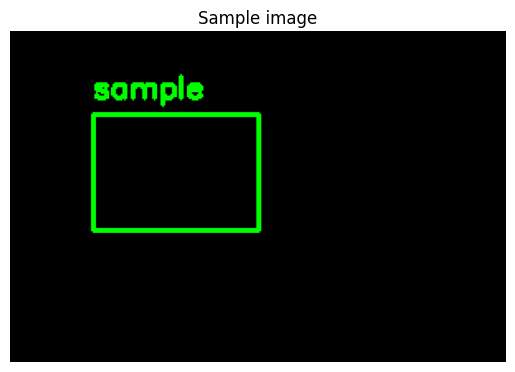

In [25]:
import numpy as np
import cv2

# Make a fake image: a black 200x300 image with 3 color channels
image = np.zeros((200, 300, 3), dtype=np.uint8)
print("image shape (height, width, channels):", image.shape)

# Draw a green rectangle (BGR: (0, 255, 0) is green) from (50,50) to (150,120)
image = cv2.rectangle(image, (50, 50), (150, 120), (0, 255, 0), 2)

# Draw a label above the box
image = cv2.putText(image, "sample", (50, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Resize it down to a smaller image
small_image = cv2.resize(image, (100, 66))
print("resized shape:", small_image.shape)

# Display it inline (matplotlib expects RGB, so convert from OpenCV's BGR first)
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Sample image")
plt.axis("off")
plt.show()

### 🏋️ Mini Exercise
Create a blank 150x150 black image (3 channels), then draw a **red** circle
(`cv2.circle(image, center, radius, color, thickness)`) at its center with radius 40.
Remember: OpenCV colors are **BGR**, so red is `(0, 0, 255)`.

In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# your code here


<details><summary>💡 Solution (click to expand)</summary>

```python
image = np.zeros((150, 150, 3), dtype=np.uint8)
image = cv2.circle(image, (75, 75), 40, (0, 0, 255), -1)  # -1 thickness = filled

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Red circle")
plt.axis("off")
plt.show()
```
</details>

## 🎉 Nice work!

You've now practiced 13 core Python, numpy, and OpenCV building blocks: f-strings, functions
with default arguments, dictionaries, tuples & unpacking, sets, comprehensions, `enumerate()` /
`zip()`, sorting with `key=` and `lambda`, `global`, error handling, string slicing, numpy
arrays, and OpenCV image basics.

If you get stuck later this week, come back to whichever section matches what's confusing
you and re-read the explanation and example.

Good luck! 🏆